# Lab 2: Seaborn From Matplotlib and pandas to Seaborn

Ross Anthony Miranda D'Angelo

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

sns.set_theme(context="paper", style="whitegrid")


1. Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galon.csv. Contruya el fit al $95$ C.L. Usar `seaborn`. Give some conclusions.     

2. Descargar el dataframe : https://github.com/anferivera/SDdiracDM/blob/master/general-scan.csv
  desde GitHUb y reconstruir la figura 6 del [trabajo](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.100.035029). Para ello usar `seaborn` y `matplolib`.

  * $M_N=h_s\dfrac{v_s}{\sqrt{2}}$
  * $v_s =$ vS
  * $h_s=$ YRC
  * $M_\Psi=$ MDF  
  * $M_{\chi_1^0}=$ mChi1
  * $\Omega_{\chi_1^0}=$ Omega
  * $\Omega_{DM}=0.12$

  



# 1. Millas por galón (mpg) vs potencia (horsepower)

Se realiza el análisis estadístico de las variables `mpg` y `horsepower` del archivo
`millas_por_galon.csv`, usando Seaborn.

El ajuste se hace al 95 % de nivel de confianza.


In [2]:
df_mpg = pd.read_csv("millas_por_galon.csv")

df_mpg.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:

df_mpg.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [4]:

data = df_mpg[["mpg", "horsepower"]].dropna()

data.describe()


,mpg,horsepower
count,392.000000,392.000000
mean,23.445918,104.469388
std,7.805007,38.491160
min,9.000000,46.000000
25%,17.000000,75.000000
50%,22.750000,93.500000
75%,29.000000,126.000000
max,46.600000,230.000000


### Diagrama de dispersión

usamos `scatterplot` para estudiar
la relación entre las dos variables numéricas.


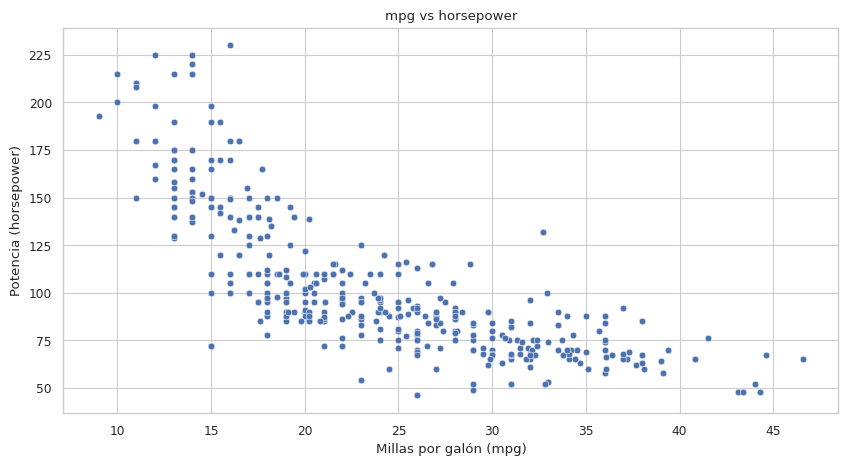

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(
    data=data,
    x="mpg",
    y="horsepower",
    ax=ax
)

ax.set_xlabel("Millas por galón (mpg)")
ax.set_ylabel("Potencia (horsepower)")
ax.set_title("mpg vs horsepower")

plt.show()


### Ajuste lineal con intervalo de confianza del 95 %

`regplot` de Seaborn permite representar simultáneamente los datos, el ajuste lineal
y la banda de confianza. El argumento `ci=95` construye el intervalo de confianza
del 95 % para la regresión.


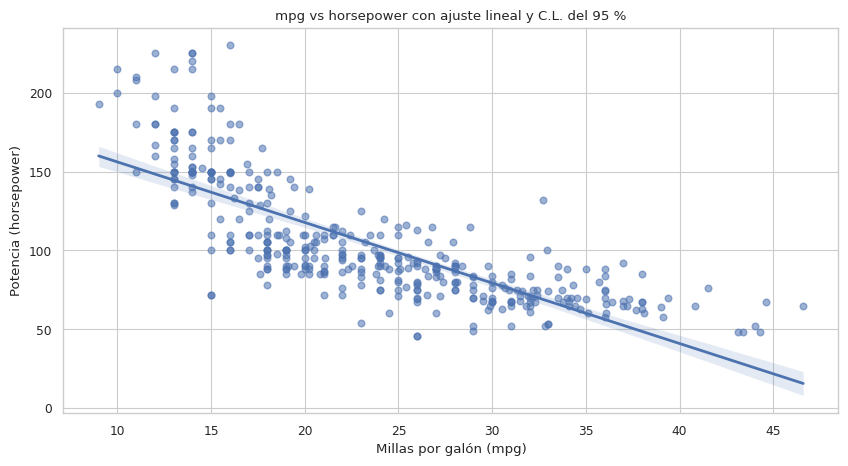

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.regplot(
    data=data,
    x="mpg",
    y="horsepower",
    ci=95,
    scatter_kws={"alpha": 0.55},
    line_kws={"linewidth": 2},
    ax=ax
)

ax.set_xlabel("Millas por galón (mpg)")
ax.set_ylabel("Potencia (horsepower)")
ax.set_title("mpg vs horsepower con ajuste lineal y C.L. del 95 %")

plt.show()


### Parámetros estadísticos del ajuste

Además de visualizar el ajuste con Seaborn, calculamos la pendiente, el intercepto,
el coeficiente de correlación, el valor de $p$, $R^2$ y el intervalo de confianza
del 95 % para la pendiente.


In [7]:
x = data["mpg"].to_numpy()
y = data["horsepower"].to_numpy()

resultado = stats.linregress(x, y)

pendiente = resultado.slope
intercepto = resultado.intercept
r = resultado.rvalue
p_value = resultado.pvalue
r2 = r**2
error_pendiente = resultado.stderr

# Intervalo de confianza del 95 % para la pendiente
n = len(x)
grados_libertad = n - 2
t_critico = stats.t.ppf(0.975, grados_libertad)

pendiente_inf = pendiente - t_critico * error_pendiente
pendiente_sup = pendiente + t_critico * error_pendiente

print(f"n = {n}")
print(f"Pendiente = {pendiente:.6f}")
print(f"Intercepto = {intercepto:.6f}")
print(f"r = {r:.6f}")
print(f"R² = {r2:.6f}")
print(f"p-value = {p_value:.6e}")
print(f"Error estándar de la pendiente = {error_pendiente:.6f}")
print(f"C.L. 95 % de la pendiente = [{pendiente_inf:.6f}, {pendiente_sup:.6f}]")


n = 392
Pendiente = -3.838888
Intercepto = 194.475643
r = -0.778427
R² = 0.605948
p-value = 7.031989e-81
Error estándar de la pendiente = 0.156759
C.L. 95 % de la pendiente = [-4.147086, -3.530690]


### Ecuación del ajuste

La recta obtenida tiene la forma

$$
y = ax+b,
$$

donde $x=mpg$ y $y=horsepower$.


In [8]:
print(
    f"horsepower = ({pendiente:.4f}) mpg + ({intercepto:.4f})"
)


horsepower = (-3.8389) mpg + (194.4756)


### Conclusiones punto 1

Las siguientes conclusiones se generan automáticamente a partir de los resultados
obtenidos con el dataset.


In [9]:
if pendiente < 0:
    tendencia = "negativa"
elif pendiente > 0:
    tendencia = "positiva"
else:
    tendencia = "prácticamente nula"

if p_value < 0.05:
    significancia = (
        "La pendiente es estadísticamente significativa al 5 %, "
        "por lo que existe evidencia de una relación lineal entre mpg y horsepower."
    )
else:
    significancia = (
        "La pendiente no es estadísticamente significativa al 5 %, "
        "por lo que no hay evidencia suficiente de una relación lineal."
    )

print(f"1. La relación lineal entre mpg y horsepower presenta una tendencia {tendencia}.")
print(f"2. El valor de R² es {r2:.4f}, por lo que el modelo lineal explica "
      f"aproximadamente {100*r2:.2f} % de la variabilidad de horsepower.")
print(f"3. {significancia}")
print(f"4. El intervalo de confianza del 95 % para la pendiente es "
      f"[{pendiente_inf:.4f}, {pendiente_sup:.4f}].")


1. La relación lineal entre mpg y horsepower presenta una tendencia negativa.
2. El valor de R² es 0.6059, por lo que el modelo lineal explica aproximadamente 60.59 % de la variabilidad de horsepower.
3. La pendiente es estadísticamente significativa al 5 %, por lo que existe evidencia de una relación lineal entre mpg y horsepower.
4. El intervalo de confianza del 95 % para la pendiente es [-4.1471, -3.5307].


# 2. Reconstrucción de la Figura 6

Se descarga el dataframe `general-scan.csv` del repositorio indicado en el laboratorio
y se construye el plano $M_\Psi$ vs $M_N$.

Las relaciones dadas en el enunciado son:

$$
M_N=h_s\frac{v_s}{\sqrt{2}},
$$

con

$$
v_s=vS,\qquad h_s=YRC,
$$

por lo que

$$
M_N=YRC\frac{vS}{\sqrt{2}}.
$$

Además,

$$
M_\Psi=MDF,\qquad
M_{\chi_1^0}=mChi1,\qquad
\Omega_{\chi_1^0}=Omega,
$$

y

$$
\Omega_{DM}=0.12.
$$


In [10]:

url = "https://raw.githubusercontent.com/anferivera/SDdiracDM/master/general-scan.csv"

df_scan = pd.read_csv(url)

df_scan.head()


,Unnamed: 0,MDF,MS12,MS22,LamS1H,LamS2H,LamSPH,LamS,LamSP,vS,...,U,mueg,taumug,sv,ZH11,ZH12,ZH21,ZH22,BRh1gg,BRh2gg
0,0,396.848661,2.137304e+06,2.137304e+06,0.020984,0.020984,0.020052,0.0,0.217236,702.109163,...,0.001075,0.0,1.773785e-19,1.860000e-26,0.999293,-0.037599,0.037599,0.999293,0.002837,0.000000
1,1,5988.499243,1.889315e+07,1.889315e+07,0.023341,0.023341,0.000181,0.0,0.019173,329.668504,...,-0.002513,0.0,1.791040e-18,2.580000e-31,0.001084,-0.999999,-0.999999,-0.001084,0.000342,0.002816
2,2,452.875632,2.469280e+06,2.469280e+06,0.000490,0.000490,0.017861,0.0,0.337367,3843.138599,...,0.000638,0.0,4.833919e-18,1.220000e-26,0.999994,-0.003384,0.003384,0.999994,0.002822,0.000000
3,3,589.443344,9.826674e+07,9.826674e+07,0.042790,0.042790,0.031174,0.0,0.270921,314.258778,...,0.000181,0.0,9.406560e-16,2.740000e-30,0.979480,-0.201541,0.201541,0.979480,0.002838,0.000194
4,4,1092.250036,2.054042e+06,2.054042e+06,0.002196,0.002196,0.002346,0.0,0.046671,13048.623894,...,0.000066,0.0,1.002187e-13,1.970000e-26,1.000000,-0.000945,0.000945,1.000000,0.002827,0.000000


In [11]:

print(df_scan.columns.tolist())
print()
df_scan.info()


['Unnamed: 0', 'MDF', 'MS12', 'MS22', 'LamS1H', 'LamS2H', 'LamSPH', 'LamS', 'LamSP', 'vS', 'YRD', 'YRC', 'YRA11', 'YRA12', 'YRA13', 'YRA21', 'YRA22', 'YRA23', 'YRB11', 'YRB12', 'YRB13', 'YRB21', 'YRB22', 'YRB23', 'mh1', 'mh2', 'mv3', 'mv2', 'mv1', 'mS1', 'mS2', 'mCha', 'mChi1', 'mChi2', 'XV11', 'XV12', 'XV21', 'XV22', 'XU11', 'XU12', 'XU21', 'XU22', 'vevSM', 'Omega', 'PSI', 'PSD', 'NSI', 'NSD', 'T', 'S', 'U', 'mueg', 'taumug', 'sv', 'ZH11', 'ZH12', 'ZH21', 'ZH22', 'BRh1gg', 'BRh2gg']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17396 entries, 0 to 17395
Data columns (total 60 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  17396 non-null  int64  
 1   MDF         17396 non-null  float64
 2   MS12        17396 non-null  float64
 3   MS22        17396 non-null  float64
 4   LamS1H      17396 non-null  float64
 5   LamS2H      17396 non-null  float64
 6   LamSPH      17396 non-null  float64
 7   LamS        17396 non-null 

In [12]:

columnas = ["vS", "YRC", "MDF", "mChi1", "Omega"]

for columna in columnas:
    df_scan[columna] = pd.to_numeric(df_scan[columna], errors="coerce")

# Eliminar filas que no tengan los datos necesarios
df_scan = df_scan.dropna(subset=columnas).copy()

# Construir las variables indicadas en el enunciado
df_scan["MN"] = df_scan["YRC"] * df_scan["vS"] / np.sqrt(2)
df_scan["MPsi"] = df_scan["MDF"]

# Omega_DM indicada en el lab
Omega_DM = 0.12

df_scan[["MN", "MPsi", "mChi1", "Omega"]].head()


,MN,MPsi,mChi1,Omega
0,132.558085,396.848661,125.748354,0.135
1,227.030952,5988.499243,227.030614,0.127
2,59.890020,452.875632,58.708865,0.133
3,206.280709,589.443344,206.197269,0.139
4,7414.553232,1092.250036,1092.250000,0.119


### Selección de los puntos con abundancia relicta correcta

El laboratorio indica que los puntos deben reproducir la abundancia de materia oscura.
Usamos una tolerancia relativa del 10 % alrededor de $\Omega_{DM}=0.12$.

Esta tolerancia puede cambiarse si el profesor indicó una condición diferente.


In [13]:
# Tolerancia usada para identificar los puntos con la abundancia correcta
tolerancia_relativa = 0.10

df_scan["relic_correcta"] = np.isclose(
    df_scan["Omega"],
    Omega_DM,
    rtol=tolerancia_relativa,
    atol=0
)

df_correct = df_scan[df_scan["relic_correcta"]].copy()

print(f"Puntos totales: {len(df_scan)}")
print(f"Puntos con abundancia relicta correcta: {len(df_correct)}")
print(f"Puntos fuera del intervalo seleccionado: {len(df_scan) - len(df_correct)}")


Puntos totales: 17396
Puntos con abundancia relicta correcta: 16899
Puntos fuera del intervalo seleccionado: 497


### Figura 6 con Seaborn + Matplotlib


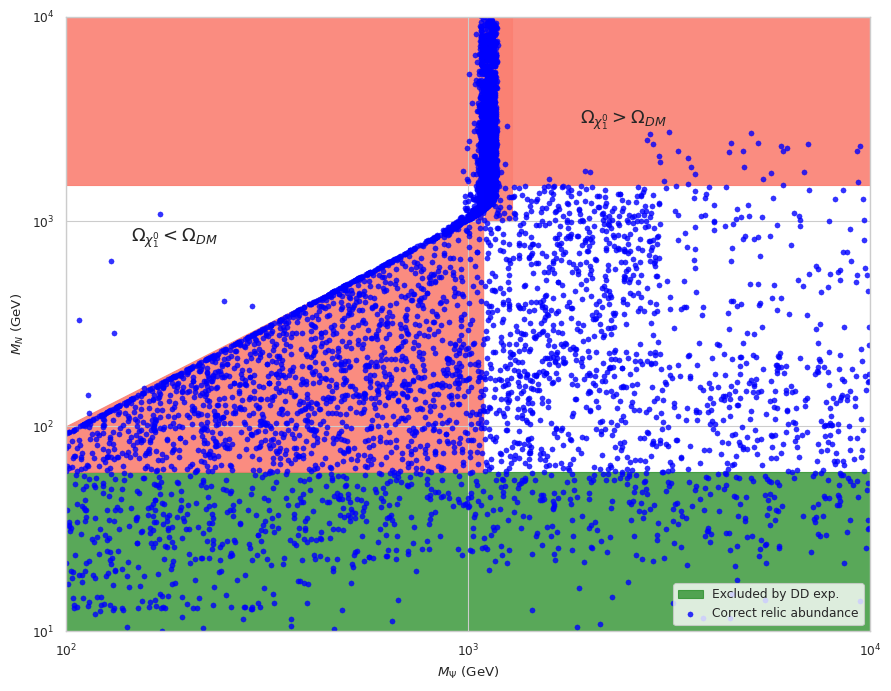

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))


ax.axhspan(
    10, 60,
    color="forestgreen",
    alpha=0.75,
    zorder=0,
    label="Excluded by DD exp."
)


x_region = np.logspace(2, 4, 500)


y_diagonal = x_region

ax.fill_between(
    x_region,
    60,
    np.minimum(y_diagonal, 1e4),
    where=(x_region <= 1.1e3),
    color="salmon",
    alpha=0.9,
    zorder=0
)


ax.fill_between(
    x_region,
    1.5e3,
    1e4,
    color="salmon",
    alpha=0.9,
    zorder=0
)


ax.fill_between(
    x_region,
    1.0e3,
    1e4,
    where=(x_region >= 1.1e3) & (x_region <= 1.3e3),
    color="salmon",
    alpha=0.9,
    zorder=0
)



sns.scatterplot(
    data=df_correct,
    x="MPsi",
    y="MN",
    color="blue",
    s=14,
    alpha=0.8,
    edgecolor=None,
    ax=ax,
    label="Correct relic abundance"
)


ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(1e2, 1e4)
ax.set_ylim(1e1, 1e4)

ax.set_xlabel(r"$M_\Psi$ (GeV)")
ax.set_ylabel(r"$M_N$ (GeV)")

# Textos
ax.text(
    1.45e2, 8.0e2,
    r"$\Omega_{\chi_1^0}<\Omega_{DM}$",
    fontsize=13
)

ax.text(
    1.9e3, 3.0e3,
    r"$\Omega_{\chi_1^0}>\Omega_{DM}$",
    fontsize=13
)


ax.legend(
    loc="lower right",
    frameon=True
)

plt.tight_layout()
plt.show()


### Versión alternativa: colorear directamente según $\Omega_{\chi_1^0}$

Esta gráfica es para comprobar que la clasificación de los puntos se está haciendo
a partir de la columna `Omega`.


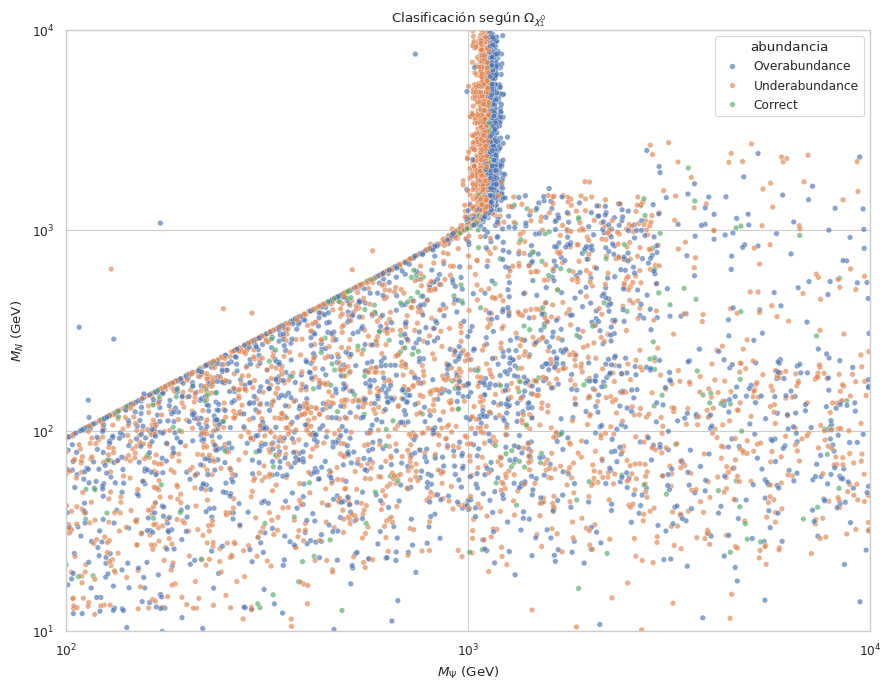

In [15]:
df_plot = df_scan.copy()

df_plot["abundancia"] = np.select(
    [
        df_plot["Omega"] < Omega_DM,
        df_plot["Omega"] > Omega_DM
    ],
    [
        "Underabundance",
        "Overabundance"
    ],
    default="Correct"
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.scatterplot(
    data=df_plot,
    x="MPsi",
    y="MN",
    hue="abundancia",
    s=16,
    alpha=0.65,
    ax=ax
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(1e2, 1e4)
ax.set_ylim(1e1, 1e4)

ax.set_xlabel(r"$M_\Psi$ (GeV)")
ax.set_ylabel(r"$M_N$ (GeV)")
ax.set_title(r"Clasificación según $\Omega_{\chi_1^0}$")

plt.tight_layout()
plt.show()


## Conclusiones punto 2

- Se transformó la información del dataframe en las variables que solicita el laboratorio.
- $M_N$ se obtuvo mediante $M_N=YRC\,vS/\sqrt{2}$.
- $M_\Psi$ se tomó directamente de `MDF`.
- La abundancia relicta se comparó con $\Omega_{DM}=0.12$.
- La representación usa `seaborn.scatterplot` para los puntos y funciones de Matplotlib
  para las regiones, escalas logarítmicas, etiquetas y leyenda.
- La distribución final permite visualizar el espacio de parámetros y distinguir la región
  de puntos compatibles con la abundancia relicta de las zonas señaladas como excluidas
  o de abundancia incorrecta en la figura de referencia.
